# 02 — Label Extraction

Extracts vulnerability labels from each train project's audit artefacts
(PDFs, bot-report.md, slither reports) and maps them to the taxonomy in
`dataset/Tag Definitions.md`.

**Outputs:** `dataset/train_labels.csv`

```
project_id | tag | subtags
```

In [14]:
%pip install pdfplumber


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent   # project root when notebook is in notebooks/
sys.path.insert(0, str(ROOT / 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from taxonomy import TAGS, SUBTAGS
from label_extractor import (
    TRAIN_DIR,
    extract_audit_text,
    split_findings,
    match_taxonomy,
    build_labels,
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

print(f'Taxonomy: {len(TAGS)} tags, {len(SUBTAGS)} subtags')
print(f'Train projects: {sum(1 for p in TRAIN_DIR.iterdir() if p.is_dir())}')

Taxonomy: 38 tags, 68 subtags
Train projects: 54


---
## 1. Inspect a single project
Verify that text extraction and finding splitting work before running the full build.

In [16]:
# Pick any train project — change the hash to explore others
SAMPLE = TRAIN_DIR / '289d8258d7b3'

text = extract_audit_text(SAMPLE)
findings = split_findings(text)

print(f'Project  : {SAMPLE.name}')
print(f'Text len : {len(text):,} chars')
print(f'Findings : {len(findings)}')
print()
print('--- First finding block (first 600 chars) ---')
print(findings[0][:600])

Project  : 289d8258d7b3
Text len : 1,216,961 chars
Findings : 188

--- First finding block (first 600 chars) ---
Smart Contract Security Assessment
February 28, 2024
Project Name:
Revert Finance - Vault
Prepared by:
HYDN
1
HYDN|RevertFinanceSmartContractAudit
Executive Summary
Client Name: Revert Finance
Language: Solidity
Timeline: Delivered 28th February 2024
Repository: https://github.com/revert-finance/lend
Method: Static Automated Analysis + Manual Review
Vulnerability Summary
2
HYDN|RevertFinanceSmartContractAudit
Contents
ExecutiveSummary 2
VulnerabilitySummary 2
Contents 3
Introduction 5
SummaryofFindings 9
ExecutiveSummary 9
ProjectSummary 9
BreakdownofFindings 10
DetailedFindings 12
1AutoCompou


In [17]:
# Match taxonomy on the first few findings
for i, f in enumerate(findings[:5]):
    tags, subtags = match_taxonomy(f)
    if tags:
        print(f'Finding {i}: {sorted(tags)}')
        print(f'  subtags: {sorted(subtags)[:6]}')

Finding 0: ['Access Control', 'Accounting Error', 'Arithmetic', 'Chainlink', 'Compound', 'DoS', 'EIP712', 'ERC20', 'ERC4626', 'ERC721', 'Flashloan', 'Governance', 'Input Validation', 'Liquidation', 'MEV', 'Opensea', 'Oracle', 'Reentrancy', 'Slippage', 'Solidity Version', 'TWAP', 'Uniswap', 'Upgradeable', 'call / delegatecall']
  subtags: ['Asset Theft', 'Block Time / Block Number', 'Bypass Mechanism', 'Centralization Risk', 'Deprecated Library', 'Fee On Transfer Token']
Finding 1: ['Chainlink', 'Oracle']
  subtags: ['Stale Value']
Finding 2: ['Chainlink', 'Oracle']
  subtags: []
Finding 3: ['Chainlink', 'Oracle']
  subtags: []
Finding 4: ['Compound', 'ERC20', 'Flashloan', 'Liquidation']
  subtags: []


---
## 2. Build labels for all train projects

> **Note:** Projects with only PDF audits require `pdfplumber`:
> ```
> pip install pdfplumber
> ```
> Projects with only PDFs and no pdfplumber will be skipped with a warning.

In [18]:
df = build_labels(TRAIN_DIR)

print(f'Rows         : {len(df)}')
print(f'Projects     : {df.project_id.nunique()}')
print(f'Unique tags  : {df.tag.nunique()}')
print()
df.head(10)

[info] 19000d572f72: no audit text found
[info] 22ad8fd6e044: no audit text found
[info] 29aba850d512: no audit text found
[info] 2c2d03025183: no audit text found
[info] 2cceea6fb3e4: no audit text found
[info] 33f83c1b20b8: no audit text found
[info] 37dd0c2e7de6: no audit text found
[info] 3a8408b6f3d4: no audit text found
[info] 4561d049a9da: no audit text found
[info] 4bea68ae8bc5: no audit text found
[info] 4dd1b2af57b2: no audit text found
[info] 50015cf871a0: no audit text found
[info] 529b81f6eb01: no audit text found
[info] 5e41ded6a8cd: no audit text found
[info] 6a503b3dea2b: no audit text found
[info] 70080e8fc005: no audit text found
[info] 727004c1c07c: no audit text found
[info] 794c62261b8d: no audit text found
[info] 82a1b82850c4: no audit text found
[info] 8b0abbf14c91: no audit text found
[info] 8ce9aae8427c: no audit text found
[info] 966f040d9bc8: no audit text found
[info] 9e1a7f778757: no audit text found
[info] a8a9998bfe4a: no audit text found
[info] ac5c6d4a2

,project_id,tag,subtags
0,1150ac69e096,ERC721,"[Arbitrary Add/Remove/Set/Call, Block Time / B..."
1,1150ac69e096,EIP712,"[Arbitrary Add/Remove/Set/Call, Block Time / B..."
2,1150ac69e096,Uniswap,"[Arbitrary Add/Remove/Set/Call, Block Time / B..."
3,1150ac69e096,Gnosis safe,"[Arbitrary Add/Remove/Set/Call, Block Time / B..."
4,1150ac69e096,call / delegatecall,"[Arbitrary Add/Remove/Set/Call, Block Time / B..."
5,1150ac69e096,DoS,"[Arbitrary Add/Remove/Set/Call, Block Time / B..."
6,1150ac69e096,Solidity Version,"[Arbitrary Add/Remove/Set/Call, Block Time / B..."
7,1150ac69e096,Arithmetic,"[Arbitrary Add/Remove/Set/Call, Block Time / B..."
8,1150ac69e096,Access Control,"[Arbitrary Add/Remove/Set/Call, Block Time / B..."
9,1150ac69e096,Governance,"[Arbitrary Add/Remove/Set/Call, Block Time / B..."


---
## 3. Coverage — which projects produced labels?

In [26]:
all_projects = {p.name for p in TRAIN_DIR.iterdir() if p.is_dir() and not p.name.startswith('__')}
labelled     = set(df.project_id.unique())
unlabelled   = all_projects - labelled

print(f'Labelled   : {len(labelled)} / {len(all_projects)}')
print(f'Unlabelled : {len(unlabelled)}')
if unlabelled:
    print('  →', sorted(unlabelled))

Labelled   : 11 / 54
Unlabelled : 43
  → ['19000d572f72', '22ad8fd6e044', '29aba850d512', '2c2d03025183', '2cceea6fb3e4', '33f83c1b20b8', '347d893744f1', '37dd0c2e7de6', '3a8408b6f3d4', '4561d049a9da', '4bea68ae8bc5', '4dd1b2af57b2', '50015cf871a0', '529b81f6eb01', '5e41ded6a8cd', '668a8ea1ed7c', '6a503b3dea2b', '70080e8fc005', '727004c1c07c', '794c62261b8d', '82a1b82850c4', '8b0abbf14c91', '8ce9aae8427c', '9007dfde367e', '966f040d9bc8', '9e1a7f778757', 'a8a9998bfe4a', 'ac5c6d4a2ace', 'b0b4fa38c58e', 'b30036fd8ad6', 'bb9c2df58c59', 'bc50c508bb4d', 'c192cb02636e', 'c9e8bb39a8ae', 'd52ee365a168', 'd5aa11e316e7', 'e269b2c934ee', 'e5f8a519b24f', 'e68d196f2fbd', 'ec394ead8172', 'edf1b6dd23d6', 'f3d2dbfd99ea', 'f4d8a18e633f']


---
## 4. Tag frequency

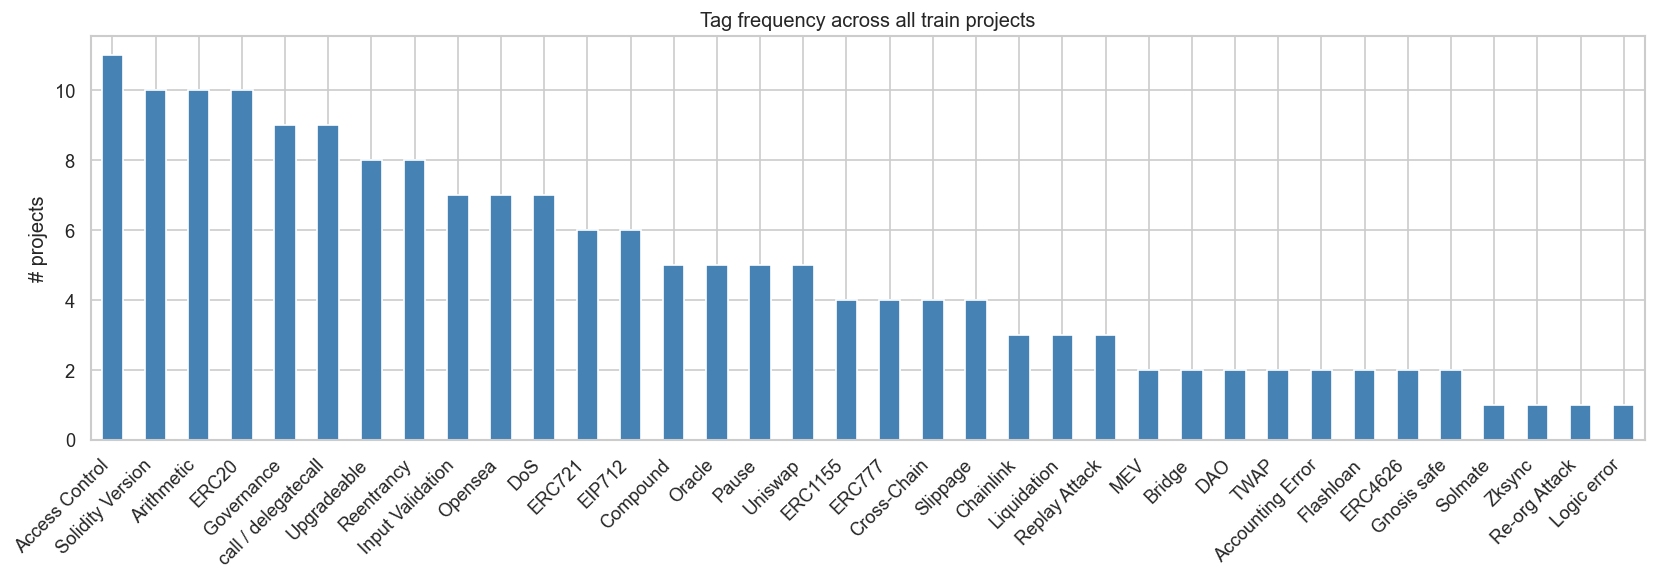

tag
Access Control         11
Solidity Version       10
Arithmetic             10
ERC20                  10
Governance              9
call / delegatecall     9
Upgradeable             8
Reentrancy              8
Input Validation        7
Opensea                 7
DoS                     7
ERC721                  6
EIP712                  6
Compound                5
Oracle                  5
Pause                   5
Uniswap                 5
ERC1155                 4
ERC777                  4
Cross-Chain             4
Slippage                4
Chainlink               3
Liquidation             3
Replay Attack           3
MEV                     2
Bridge                  2
DAO                     2
TWAP                    2
Accounting Error        2
Flashloan               2
ERC4626                 2
Gnosis safe             2
Solmate                 1
Zksync                  1
Re-org Attack           1
Logic error             1


In [27]:
tag_counts = df.tag.value_counts()

fig, ax = plt.subplots(figsize=(14, 5))
tag_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Tag frequency across all train projects')
ax.set_xlabel('')
ax.set_ylabel('# projects')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(tag_counts.to_string())

---
## 5. Tags per project (multi-label density)

count    11.000000
mean     15.727273
std       5.330871
min      10.000000
25%      11.500000
50%      15.000000
75%      19.500000
max      27.000000
Name: tag, dtype: float64


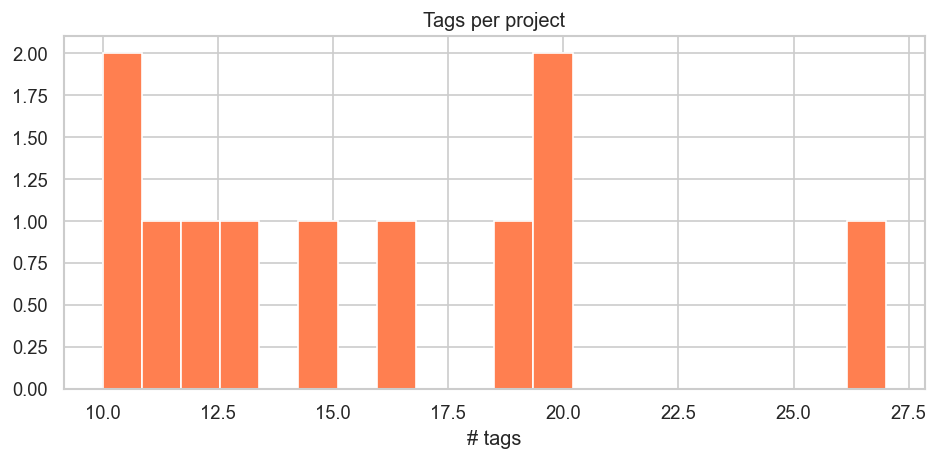

In [28]:
tags_per_project = df.groupby('project_id')['tag'].count()
print(tags_per_project.describe())

fig, ax = plt.subplots(figsize=(8, 4))
tags_per_project.hist(bins=20, ax=ax, color='coral', edgecolor='white')
ax.set_title('Tags per project')
ax.set_xlabel('# tags')
plt.tight_layout()
plt.show()

---
## 6. Tag co-occurrence heatmap

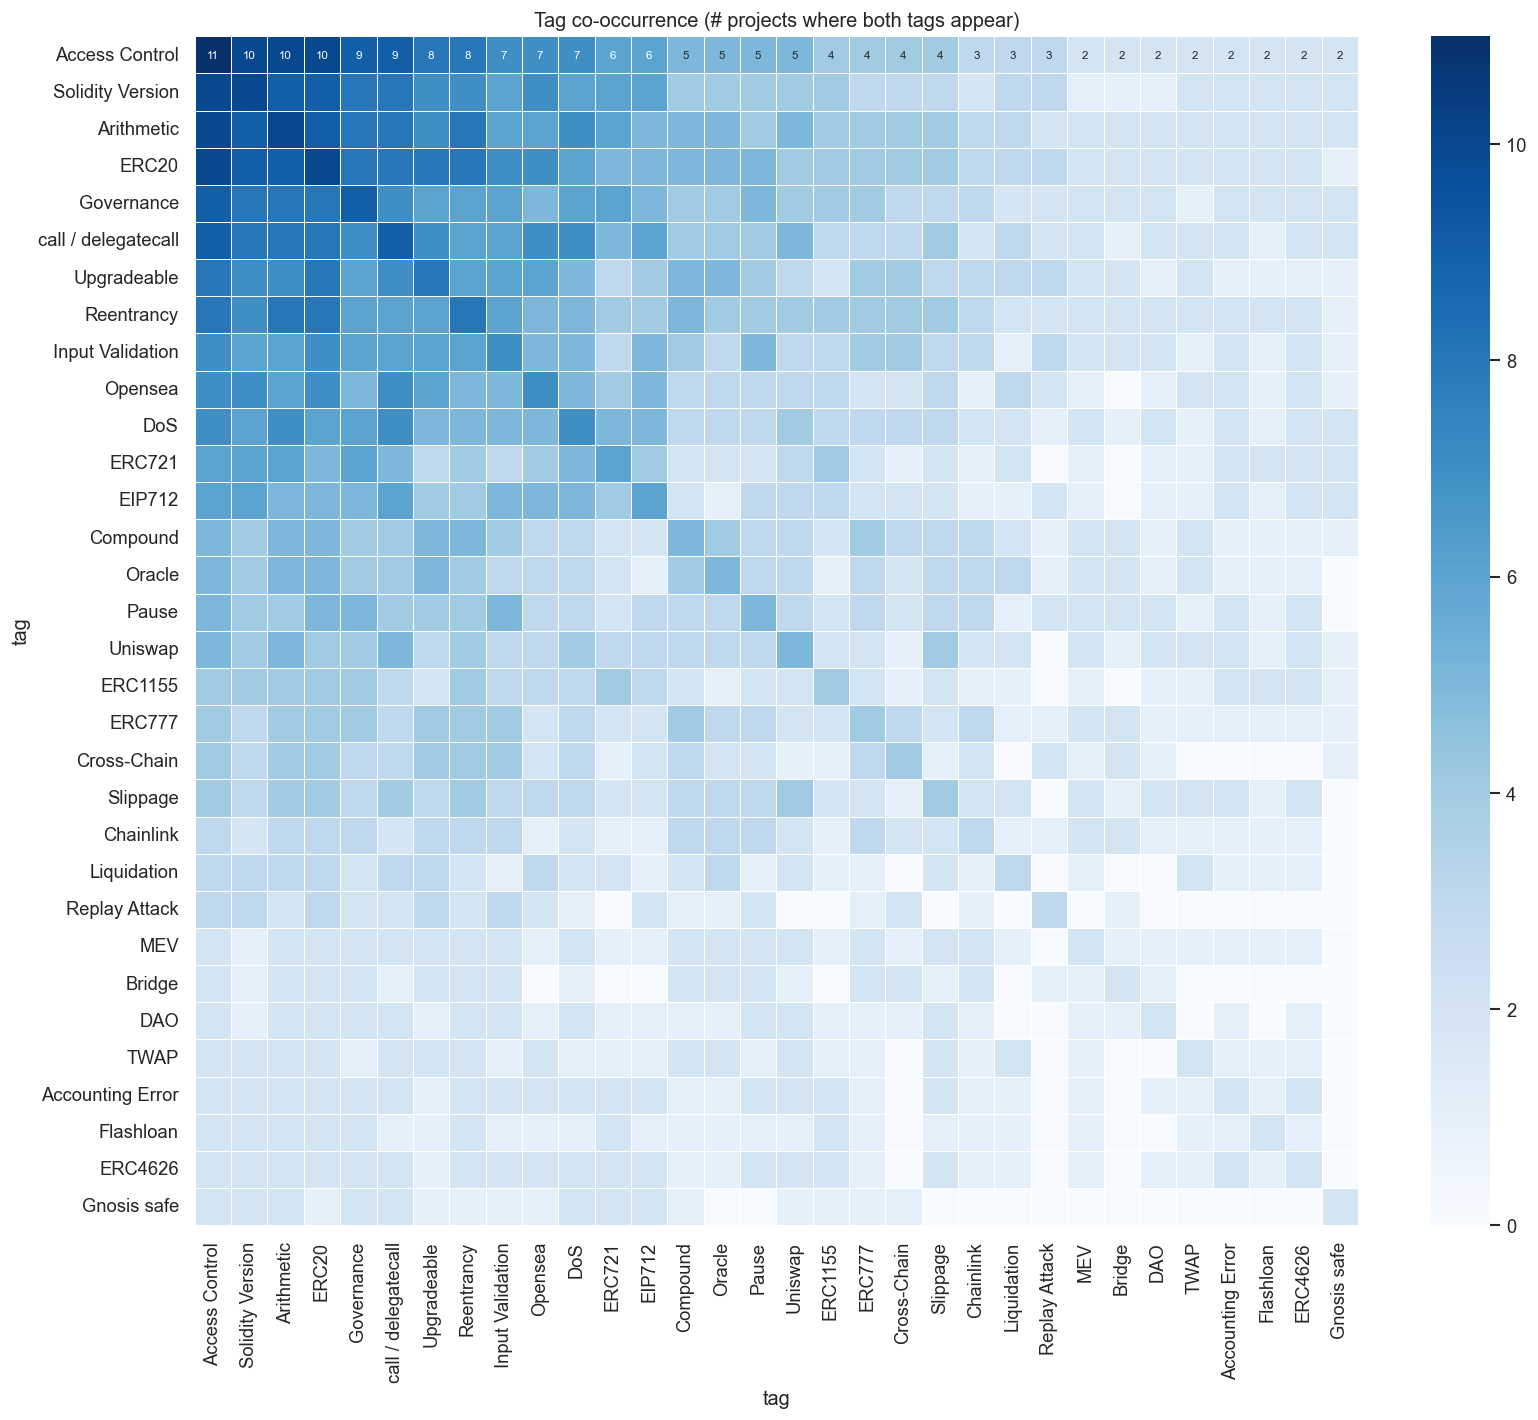

In [29]:
# Build project × tag binary matrix
pivot = df.assign(val=1).pivot_table(
    index='project_id', columns='tag', values='val', aggfunc='max', fill_value=0
)

# Keep tags with >= 2 occurrences for readability
common_tags = tag_counts[tag_counts >= 2].index
pivot_filt  = pivot.reindex(columns=[c for c in common_tags if c in pivot.columns])

cooc = pivot_filt.T @ pivot_filt

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cooc, ax=ax, cmap='Blues', linewidths=0.3, annot=True, fmt='d', annot_kws={'size': 7})
ax.set_title('Tag co-occurrence (# projects where both tags appear)')
plt.tight_layout()
plt.show()

---
## 7. Review unlabelled projects
These either have no audit artefacts or are PDF-only (needs pdfplumber).

In [30]:
from label_extractor import _collect_audit_files

for pid in sorted(unlabelled):
    proj = TRAIN_DIR / pid
    files = _collect_audit_files(proj)
    print(f'{pid}: {[f.name for f in files] or "NO AUDIT FILES"}')

19000d572f72: NO AUDIT FILES
22ad8fd6e044: NO AUDIT FILES
29aba850d512: NO AUDIT FILES
2c2d03025183: NO AUDIT FILES
2cceea6fb3e4: NO AUDIT FILES
33f83c1b20b8: NO AUDIT FILES
347d893744f1: ['audit-item.md']
37dd0c2e7de6: NO AUDIT FILES
3a8408b6f3d4: NO AUDIT FILES
4561d049a9da: NO AUDIT FILES
4bea68ae8bc5: NO AUDIT FILES
4dd1b2af57b2: NO AUDIT FILES
50015cf871a0: NO AUDIT FILES
529b81f6eb01: NO AUDIT FILES
5e41ded6a8cd: NO AUDIT FILES
668a8ea1ed7c: ['audit-item.md']
6a503b3dea2b: NO AUDIT FILES
70080e8fc005: NO AUDIT FILES
727004c1c07c: NO AUDIT FILES
794c62261b8d: NO AUDIT FILES
82a1b82850c4: NO AUDIT FILES
8b0abbf14c91: NO AUDIT FILES
8ce9aae8427c: NO AUDIT FILES
9007dfde367e: ['audit-item.md']
966f040d9bc8: NO AUDIT FILES
9e1a7f778757: NO AUDIT FILES
a8a9998bfe4a: NO AUDIT FILES
ac5c6d4a2ace: NO AUDIT FILES
b0b4fa38c58e: NO AUDIT FILES
b30036fd8ad6: NO AUDIT FILES
bb9c2df58c59: NO AUDIT FILES
bc50c508bb4d: ['audit-item.md']
c192cb02636e: ['audit-item.md']
c9e8bb39a8ae: NO AUDIT FILES

---
## 8. Save `train_labels.csv`

In [31]:
out = ROOT / 'dataset' / 'train_labels.csv'
df.to_csv(out, index=False)
print(f'Saved → {out}')
print(f'{len(df)} rows')

Saved → /Users/j6s1yn8z/LLM Identification of Smart Contract Vulnerabilities/dataset/train_labels.csv
173 rows
